In [8]:
#Importing libraries
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import backend as k
from tensorflow.keras.datasets import cifar10

In [9]:
#loading dataset
((x_train,y_train),(x_test,y_test))= cifar10.load_data()

170498071/170498071 [==============================] - 808s 5us/step


array([[0.23137255, 0.24313726, 0.24705882, ..., 0.48235294, 0.36078432,
        0.28235295],
       [0.6039216 , 0.69411767, 0.73333335, ..., 0.56078434, 0.52156866,
        0.5647059 ],
       [1.        , 1.        , 1.        , ..., 0.3137255 , 0.3372549 ,
        0.32941177],
       ...,
       [0.13725491, 0.69803923, 0.92156863, ..., 0.04705882, 0.12156863,
        0.19607843],
       [0.7411765 , 0.827451  , 0.9411765 , ..., 0.7647059 , 0.74509805,
        0.67058825],
       [0.8980392 , 0.8980392 , 0.9372549 , ..., 0.6392157 , 0.6392157 ,
        0.6313726 ]], dtype=float32)

In [10]:
# preprocessing- reshaping + normalization+ encoding
x_train= x_train.reshape(x_train.shape[0],32*32*3)
x_test=x_test.reshape(x_test.shape[0],32*32*3)

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

LB=LabelBinarizer()
y_train=LB.fit_transform(y_train)
y_test= LB.transform(y_test)

In [11]:
#defining the network architecture using sequential
model= Sequential()
model.add( Dense(512,input_shape=(3072,), activation="relu") )
model.add( Dense(256,activation="relu") )
model.add( Dense(10,activation="softmax"))


In [12]:
#training the model using sgd
sgd= SGD(0.01)
epochs=100
model.compile( loss="categorical_crossentropy", metrics=["accuracy"], optimizer=sgd)
H=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=epochs,batch_size=32)


Epoch 1/100
1563/1563 [==============================] - 24s 13ms/step - loss: 1.8512 - accuracy: 0.3367 - val_loss: 1.6996 - val_accuracy: 0.4049
Epoch 2/100
1563/1563 [==============================] - 19s 12ms/step - loss: 1.6679 - accuracy: 0.4124 - val_loss: 1.7868 - val_accuracy: 0.3772
Epoch 3/100
1563/1563 [==============================] - 19s 12ms/step - loss: 1.5867 - accuracy: 0.4404 - val_loss: 1.6695 - val_accuracy: 0.4092
Epoch 4/100
1563/1563 [==============================] - 20s 13ms/step - loss: 1.5304 - accuracy: 0.4576 - val_loss: 1.5160 - val_accuracy: 0.4565
Epoch 5/100
1563/1563 [==============================] - 21s 13ms/step - loss: 1.4830 - accuracy: 0.4743 - val_loss: 1.5828 - val_accuracy: 0.4308
Epoch 6/100
1563/1563 [==============================] - 21s 14ms/step - loss: 1.4431 - accuracy: 0.4918 - val_loss: 1.5015 - val_accuracy: 0.4683
Epoch 7/100
1563/1563 [==============================] - 22s 14ms/step - loss: 1.4083 - accuracy: 0.5034 - val_loss: 1

1563/1563 [==============================] - 23s 14ms/step - loss: 0.5446 - accuracy: 0.8116 - val_loss: 1.5683 - val_accuracy: 0.5255
Epoch 57/100
1563/1563 [==============================] - 22s 14ms/step - loss: 0.5280 - accuracy: 0.8180 - val_loss: 1.6945 - val_accuracy: 0.5129
Epoch 58/100
1563/1563 [==============================] - 21s 14ms/step - loss: 0.5148 - accuracy: 0.8230 - val_loss: 1.6127 - val_accuracy: 0.5445
Epoch 59/100
1563/1563 [==============================] - 21s 13ms/step - loss: 0.5010 - accuracy: 0.8274 - val_loss: 1.6511 - val_accuracy: 0.5343
Epoch 60/100
1563/1563 [==============================] - 22s 14ms/step - loss: 0.4877 - accuracy: 0.8334 - val_loss: 1.6220 - val_accuracy: 0.5462
Epoch 61/100
1563/1563 [==============================] - 21s 13ms/step - loss: 0.4760 - accuracy: 0.8358 - val_loss: 1.7366 - val_accuracy: 0.5217
Epoch 62/100
1563/1563 [==============================] - 21s 13ms/step - loss: 0.4627 - accuracy: 0.8416 - val_loss: 1.7435 

In [20]:
#evaluation of model
y_pred= model.predict(x_test, batch_size=32)

print( classification_report(y_test.argmax(axis=1),y_pred.argmax(axis=1)) )

313/313 [==============================] - 2s 3ms/step
              precision    recall  f1-score   support

           0       0.62      0.64      0.63      1000
           1       0.71      0.61      0.65      1000
           2       0.46      0.47      0.46      1000
           3       0.39      0.34      0.37      1000
           4       0.49      0.50      0.50      1000
           5       0.46      0.46      0.46      1000
           6       0.59      0.62      0.61      1000
           7       0.61      0.60      0.60      1000
           8       0.68      0.68      0.68      1000
           9       0.55      0.65      0.60      1000

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.56     10000
weighted avg       0.56      0.56      0.56     10000



Text(0.5, 1.0, 'training accuracy & loss')

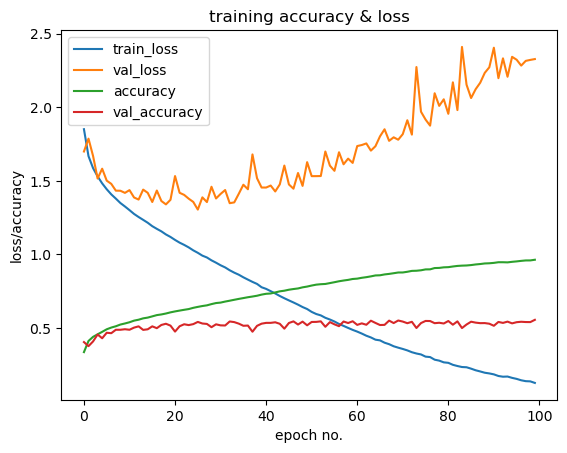

In [23]:
#plotting the graph
plt.plot( np.arange(0,100), H.history["loss"] ,label="train_loss" )
plt.plot(np.arange(0,100), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0,100), H.history["accuracy"], label="accuracy")
plt.plot(np.arange(0,100), H.history["val_accuracy"], label="val_accuracy")
plt.xlabel("epoch no.")
plt.ylabel("loss/accuracy")
plt.legend()
plt.title("training accuracy & loss")
